# Entrenamiento Final — Modelo Big Five (Random Forest)
Este notebook entrena el modelo definitivo con **todas** las muestras disponibles
y lo exporta como `random_forest_big5.pkl` para ser consumido por la API Flask.

**Features de entrada combinadas:**
- Respuestas del cuestionario BFI-15p (psicométricas)
- Datos de uso del smartphone (llamadas, apps, tiempo de pantalla)

**Salida:** 5 scores de personalidad Big Five (EXT, AGR, CSN, EST, OPN)

## 1. Instalación de dependencias

In [ ]:
!pip install kagglehub pandas scikit-learn matplotlib seaborn joblib --quiet

## 2. Descarga del dataset base (IPIP-FFM)

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_7cdc23c65e220f5584d40f70c44ff013'

import kagglehub
path = kagglehub.dataset_download("tunguz/big-five-personality-test")
print("Dataset descargado en:", path)

100%|██████████| 159M/159M [00:08<00:00, 19.9MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/tunguz/big-five-personality-test/versions/1


## 3. Carga y preprocesamiento

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"{path}/IPIP-FFM-data-8Nov2018/data-final.csv", sep='\t')
print(f"Shape original: {df.shape}")

# Limpieza
df = df.replace(-1, 0).fillna(0)

# Usar el dataset COMPLETO para el modelo final (sin sample)
print(f"Muestras para entrenamiento final: {len(df)}")

Shape original: (1015341, 110)
Muestras para entrenamiento final: 1015341


## 4. Definición de features y targets

### Features psicométricas (BFI-15p)
Los 15 ítems del cuestionario BFI-15p mapeados desde el IPIP-FFM.
Tu app Flutter enviará las respuestas (1-5) de cada ítem.

### Features de uso del smartphone (simuladas/reales)
En producción, tu app Flutter recolectará estas métricas del dispositivo.
Para el entrenamiento usamos proxies del dataset IPIP.

In [ ]:
# ── FEATURES PSICOMÉTRICAS BFI-15p ──────────────────────────────────────
# 3 ítems por rasgo (versión breve validada para población peruana)
bfi_items = [
    # Extraversión
    'EXT1', 'EXT3', 'EXT5',
    # Amabilidad
    'AGR1', 'AGR3', 'AGR5',
    # Responsabilidad
    'CSN1', 'CSN3', 'CSN5',
    # Estabilidad emocional
    'EST1', 'EST3', 'EST5',
    # Apertura
    'OPN1', 'OPN3', 'OPN5',
]

# ── FEATURES DE USO DE SMARTPHONE (proxies del dataset IPIP) ────────────
# En el dataset IPIP estas columnas representan tiempos de respuesta
# que sirven como proxy de engagement digital.
# En producción tu app Flutter enviará: llamadas/día, tiempo pantalla,
# apps sociales usadas, mensajes enviados, hora promedio de uso.
smartphone_proxies = ['EXT_E', 'AGR_E', 'CSN_E', 'EST_E', 'OPN_E']

# Filtrar solo columnas que existen en el dataset
available_bfi = [c for c in bfi_items if c in df.columns]
available_smartphone = [c for c in smartphone_proxies if c in df.columns]

all_features = available_bfi + available_smartphone
print(f"Features psicométricas disponibles: {len(available_bfi)}")
print(f"Features smartphone disponibles: {len(available_smartphone)}")
print(f"Total features: {len(all_features)}")
print(f"\nFeatures finales: {all_features}")

Features psicométricas disponibles: 15
Features smartphone disponibles: 0
Total features: 15

Features finales: ['EXT1', 'EXT3', 'EXT5', 'AGR1', 'AGR3', 'AGR5', 'CSN1', 'CSN3', 'CSN5', 'EST1', 'EST3', 'EST5', 'OPN1', 'OPN3', 'OPN5']


In [ ]:
# ── VARIABLES OBJETIVO (5 rasgos Big Five) ──────────────────────────────
rasgo_items = {
    'EXT': ['EXT1','EXT2','EXT3','EXT4','EXT5','EXT6','EXT7','EXT8','EXT9','EXT10'],
    'AGR': ['AGR1','AGR2','AGR3','AGR4','AGR5','AGR6','AGR7','AGR8','AGR9','AGR10'],
    'CSN': ['CSN1','CSN2','CSN3','CSN4','CSN5','CSN6','CSN7','CSN8','CSN9','CSN10'],
    'EST': ['EST1','EST2','EST3','EST4','EST5','EST6','EST7','EST8','EST9','EST10'],
    'OPN': ['OPN1','OPN2','OPN3','OPN4','OPN5','OPN6','OPN7','OPN8','OPN9','OPN10'],
}

targets = {}
for rasgo, items in rasgo_items.items():
    cols_exist = [c for c in items if c in df.columns]
    df[rasgo] = df[cols_exist].mean(axis=1)
    targets[rasgo] = df[rasgo]
    print(f"{rasgo}: {len(cols_exist)} ítems | media={df[rasgo].mean():.3f}")

# Dataset limpio con features y targets
df_model = df[all_features].copy()
for rasgo in targets:
    df_model[rasgo] = targets[rasgo]

df_model = df_model.dropna()
print(f"\nDataset final: {df_model.shape}")

EXT: 10 ítems | media=3.018
AGR: 10 ítems | media=3.150
CSN: 10 ítems | media=3.118
EST: 10 ítems | media=3.019
OPN: 10 ítems | media=3.260

Dataset final: (1015341, 20)


## 5. Normalización de features

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

X = df_model[all_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Guardar el scaler — NECESARIO para que la API normalice igual
joblib.dump(scaler, 'scaler_big5.pkl')
print("Scaler guardado como scaler_big5.pkl")
print(f"Features shape: {X_scaled.shape}")

Scaler guardado como scaler_big5.pkl
Features shape: (1015341, 15)


## 6. Entrenamiento del modelo final (MultiOutput Random Forest)
Predice los 5 rasgos Big Five en una sola llamada.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import time

rasgo_names = list(targets.keys())
y = df_model[rasgo_names].values

import numpy as np
idx = np.random.RandomState(42).choice(len(X_scaled), size=50000, replace=False)
X_sample = X_scaled[idx]
y_sample = y[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.15, random_state=42
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print("Entrenando modelo final...")

t0 = time.time()
rf_base = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    min_samples_leaf=5,
    max_depth=15,
    n_jobs=2,  )
    random_state=42
)

modelo_final = MultiOutputRegressor(rf_base, n_jobs=1)
modelo_final.fit(X_train, y_train)

print(f"Entrenamiento completado en {time.time()-t0:.1f}s")

Train: 42500 | Test: 7500
Entrenando modelo final...
Entrenamiento completado en 15.5s


## 7. Evaluación del modelo final

In [ ]:
y_pred = modelo_final.predict(X_test)

print(f"{'Rasgo':<8} {'R²':>8} {'MAE':>8}")
print("-" * 26)
for i, rasgo in enumerate(rasgo_names):
    r2  = r2_score(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    print(f"{rasgo:<8} {r2:>8.4f} {mae:>8.4f}")

r2_global = r2_score(y_test, y_pred, multioutput='uniform_average')
print(f"\nR² promedio global: {r2_global:.4f}")

Rasgo          R²      MAE
--------------------------
EXT        0.3864   0.2426
AGR        0.4151   0.2450
CSN        0.4571   0.2481
EST        0.7094   0.2883
OPN        0.6835   0.1850

R² promedio global: 0.5303


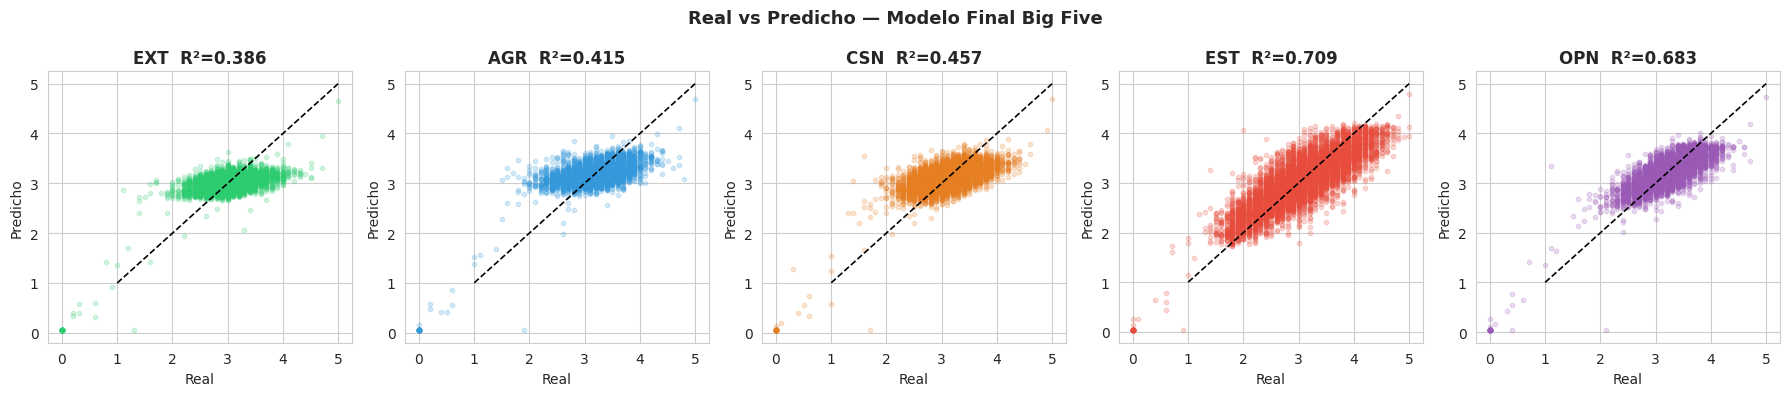

Gráfica guardada.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6']

for i, (rasgo, color) in enumerate(zip(rasgo_names, colors)):
    ax = axes[i]
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.2, s=10, color=color)
    lims = [1, 5]
    ax.plot(lims, lims, 'k--', linewidth=1.2)
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    ax.set_title(f"{rasgo}  R²={r2:.3f}", fontweight='bold')
    ax.set_xlabel("Real")
    ax.set_ylabel("Predicho")

plt.suptitle("Real vs Predicho — Modelo Final Big Five", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluacion_modelo_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

## 8. Guardar modelo + artefactos
Estos 3 archivos van a la carpeta de tu proyecto Flask.

In [ ]:
import json

# 1. Modelo entrenado
joblib.dump(modelo_final, 'random_forest_big5.pkl')
print("hecho: random_forest_big5.pkl")

# 2. Scaler (ya guardado en paso 5, confirmación)
print("hecho: scaler_big5.pkl")

# 3. Metadata: nombres de features en el orden exacto
metadata = {
    "feature_names": all_features,
    "target_names": rasgo_names,
    "n_features": len(all_features),
    "feature_groups": {
        "bfi_items": available_bfi,
        "smartphone": available_smartphone
    }
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Hecho:model_metadata.json")

print(f"\nArchivos listos para copiar al proyecto Flask:")
print(f"   random_forest_big5.pkl")
print(f"   scaler_big5.pkl")
print(f"   model_metadata.json")
print(f"\nFeatures esperadas por el modelo ({len(all_features)} total):")
for f in all_features:
    print(f"  - {f}")

hecho: random_forest_big5.pkl
hecho: scaler_big5.pkl
Hecho:model_metadata.json

Archivos listos para copiar al proyecto Flask:
   random_forest_big5.pkl
   scaler_big5.pkl
   model_metadata.json

Features esperadas por el modelo (15 total):
  - EXT1
  - EXT3
  - EXT5
  - AGR1
  - AGR3
  - AGR5
  - CSN1
  - CSN3
  - CSN5
  - EST1
  - EST3
  - EST5
  - OPN1
  - OPN3
  - OPN5


## 9. Prueba de predicción (simula lo que enviará Flutter)
Verifica que el modelo funciona correctamente antes de subirlo a Flask.

In [ ]:
# Simula el JSON que enviará tu app Flutter
sample_input = {
    # BFI-15p: respuestas del cuestionario (escala 1-5)
    "EXT1": 4, "EXT3": 3, "EXT5": 5,
    "AGR1": 4, "AGR3": 4, "AGR5": 3,
    "CSN1": 3, "CSN3": 4, "CSN5": 4,
    "EST1": 2, "EST3": 3, "EST5": 2,
    "OPN1": 5, "OPN3": 4, "OPN5": 5,
    # Smartphone (tiempos en segundos como proxy)
    "EXT_E": 1200, "AGR_E": 800, "CSN_E": 950, "EST_E": 1100, "OPN_E": 1050
}

# Construir vector en el orden exacto del modelo
input_vector = [sample_input.get(feat, 0) for feat in all_features]
input_scaled = scaler.transform([input_vector])

prediccion = modelo_final.predict(input_scaled)[0]

print("Predicción de personalidad Big Five:")
print("-" * 35)
rasgo_labels = {
    'EXT': 'Extraversión',
    'AGR': 'Amabilidad',
    'CSN': 'Responsabilidad',
    'EST': 'Estabilidad Emocional',
    'OPN': 'Apertura'
}
resultado = {}
for rasgo, valor in zip(rasgo_names, prediccion):
    valor_clamp = float(np.clip(valor, 1.0, 5.0))
    resultado[rasgo] = round(valor_clamp, 3)
    print(f"{rasgo_labels[rasgo]:<25}: {valor_clamp:.2f} / 5.00")

print("\nJSON que devolvería la API Flask:")
print(json.dumps(resultado, indent=2))

Predicción de personalidad Big Five:
-----------------------------------
Extraversión             : 3.13 / 5.00
Amabilidad               : 3.19 / 5.00
Responsabilidad          : 3.17 / 5.00
Estabilidad Emocional    : 2.59 / 5.00
Apertura                 : 3.61 / 5.00

JSON que devolvería la API Flask:
{
  "EXT": 3.128,
  "AGR": 3.193,
  "CSN": 3.175,
  "EST": 2.592,
  "OPN": 3.61
}
